In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error,r2_score

In [2]:
df=pd.read_csv("last_mile_delivery_dataset.csv")

In [3]:
df.head()

,order_id,order_date,order_time,city,zone,rider_id,vehicle_type,order_type,distance_km,promised_delivery_mins,actual_delivery_mins,delay_mins,delivery_status,weather_condition,order_value_inr,delivery_attempts,rider_experience_yrs,rider_rating,gps_latitude,gps_longitude
0,ORD000001,2024-09-02,13:10,Chennai,East,RID0022,Cycle,Electronics,11.05,60,57.4,-2.6,On-Time,Partly Cloudy,377.96,1,7.9,4.6,28.9867,87.3825
1,ORD000002,2024-09-13,14:53,Delhi,East,RID0100,cycle,Electronics,14.75,30,29.7,-0.3,On-Time,Clear,1352.80,1,0.4,4.5,36.7618,84.6386
2,ORD000003,2024-02-28,18:01,Lucknow,NaN,RID0010,Bike,Documents,11.21,60,87.0,27.0,Delayed,Clear,1302.15,2,7.8,3.4,NaN,NaN
3,ORD000004,2024-07-13,14:59,Chennai,North,RID0050,AUTO,Documents,10.27,30,57.2,27.2,Delayed,Rain,3308.73,1,6.8,4.4,17.7429,71.3316
4,ORD000005,2024-07-24,14:28,Jaipur,South,RID0078,Bike,Apparel,13.07,60,55.5,-4.5,On-Time,Partly Cloudy,3095.74,2,1.1,3.1,22.9501,96.4950


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2080 entries, 0 to 2079
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   order_id                2080 non-null   object 
 1   order_date              2080 non-null   object 
 2   order_time              2080 non-null   object 
 3   city                    2080 non-null   object 
 4   zone                    1944 non-null   object 
 5   rider_id                1967 non-null   object 
 6   vehicle_type            2080 non-null   object 
 7   order_type              2080 non-null   object 
 8   distance_km             2080 non-null   float64
 9   promised_delivery_mins  2080 non-null   int64  
 10  actual_delivery_mins    2080 non-null   object 
 11  delay_mins              2080 non-null   float64
 12  delivery_status         2080 non-null   object 
 13  weather_condition       2080 non-null   object 
 14  order_value_inr         2080 non-null   

In [5]:
df.isnull().sum()

order_id                    0
order_date                  0
order_time                  0
city                        0
zone                      136
rider_id                  113
vehicle_type                0
order_type                  0
distance_km                 0
promised_delivery_mins      0
actual_delivery_mins        0
delay_mins                  0
delivery_status             0
weather_condition           0
order_value_inr             0
delivery_attempts           0
rider_experience_yrs        0
rider_rating                0
gps_latitude              137
gps_longitude             137
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df['order_id']

0       ORD000001
1       ORD000002
2       ORD000003
3       ORD000004
4       ORD000005
          ...    
2075    ORD002076
2076    ORD002077
2077    ORD002078
2078    ORD002079
2079    ORD002080
Name: order_id, Length: 2080, dtype: object

In [8]:
df['order_id']=df.index+1

In [9]:
df.head()

,order_id,order_date,order_time,city,zone,rider_id,vehicle_type,order_type,distance_km,promised_delivery_mins,actual_delivery_mins,delay_mins,delivery_status,weather_condition,order_value_inr,delivery_attempts,rider_experience_yrs,rider_rating,gps_latitude,gps_longitude
0,1,2024-09-02,13:10,Chennai,East,RID0022,Cycle,Electronics,11.05,60,57.4,-2.6,On-Time,Partly Cloudy,377.96,1,7.9,4.6,28.9867,87.3825
1,2,2024-09-13,14:53,Delhi,East,RID0100,cycle,Electronics,14.75,30,29.7,-0.3,On-Time,Clear,1352.80,1,0.4,4.5,36.7618,84.6386
2,3,2024-02-28,18:01,Lucknow,NaN,RID0010,Bike,Documents,11.21,60,87.0,27.0,Delayed,Clear,1302.15,2,7.8,3.4,NaN,NaN
3,4,2024-07-13,14:59,Chennai,North,RID0050,AUTO,Documents,10.27,30,57.2,27.2,Delayed,Rain,3308.73,1,6.8,4.4,17.7429,71.3316
4,5,2024-07-24,14:28,Jaipur,South,RID0078,Bike,Apparel,13.07,60,55.5,-4.5,On-Time,Partly Cloudy,3095.74,2,1.1,3.1,22.9501,96.4950


In [10]:
df['order_year'] =df['order_date'].str.split('-').str[0]
df['order_month'] =df['order_date'].str.split('-').str[1]
df['order_day'] =df['order_date'].str.split('-').str[2]

In [11]:
df.head()

,order_id,order_date,order_time,city,zone,rider_id,vehicle_type,order_type,distance_km,promised_delivery_mins,...,weather_condition,order_value_inr,delivery_attempts,rider_experience_yrs,rider_rating,gps_latitude,gps_longitude,order_year,order_month,order_day
0,1,2024-09-02,13:10,Chennai,East,RID0022,Cycle,Electronics,11.05,60,...,Partly Cloudy,377.96,1,7.9,4.6,28.9867,87.3825,2024,09,02
1,2,2024-09-13,14:53,Delhi,East,RID0100,cycle,Electronics,14.75,30,...,Clear,1352.80,1,0.4,4.5,36.7618,84.6386,2024,09,13
2,3,2024-02-28,18:01,Lucknow,NaN,RID0010,Bike,Documents,11.21,60,...,Clear,1302.15,2,7.8,3.4,NaN,NaN,2024,02,28
3,4,2024-07-13,14:59,Chennai,North,RID0050,AUTO,Documents,10.27,30,...,Rain,3308.73,1,6.8,4.4,17.7429,71.3316,2024,07,13
4,5,2024-07-24,14:28,Jaipur,South,RID0078,Bike,Apparel,13.07,60,...,Partly Cloudy,3095.74,2,1.1,3.1,22.9501,96.4950,2024,07,24


In [12]:
df['order_year']=df['order_year'].astype('int')
df['order_month']=df['order_month'].astype('int')
df['order_day']=df['order_day'].astype('int')

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2080 entries, 0 to 2079
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   order_id                2080 non-null   int64  
 1   order_date              2080 non-null   object 
 2   order_time              2080 non-null   object 
 3   city                    2080 non-null   object 
 4   zone                    1944 non-null   object 
 5   rider_id                1967 non-null   object 
 6   vehicle_type            2080 non-null   object 
 7   order_type              2080 non-null   object 
 8   distance_km             2080 non-null   float64
 9   promised_delivery_mins  2080 non-null   int64  
 10  actual_delivery_mins    2080 non-null   object 
 11  delay_mins              2080 non-null   float64
 12  delivery_status         2080 non-null   object 
 13  weather_condition       2080 non-null   object 
 14  order_value_inr         2080 non-null   

In [14]:
df.drop('order_date',axis=1,inplace=True)

In [15]:
df.head()

,order_id,order_time,city,zone,rider_id,vehicle_type,order_type,distance_km,promised_delivery_mins,actual_delivery_mins,...,weather_condition,order_value_inr,delivery_attempts,rider_experience_yrs,rider_rating,gps_latitude,gps_longitude,order_year,order_month,order_day
0,1,13:10,Chennai,East,RID0022,Cycle,Electronics,11.05,60,57.4,...,Partly Cloudy,377.96,1,7.9,4.6,28.9867,87.3825,2024,9,2
1,2,14:53,Delhi,East,RID0100,cycle,Electronics,14.75,30,29.7,...,Clear,1352.80,1,0.4,4.5,36.7618,84.6386,2024,9,13
2,3,18:01,Lucknow,NaN,RID0010,Bike,Documents,11.21,60,87.0,...,Clear,1302.15,2,7.8,3.4,NaN,NaN,2024,2,28
3,4,14:59,Chennai,North,RID0050,AUTO,Documents,10.27,30,57.2,...,Rain,3308.73,1,6.8,4.4,17.7429,71.3316,2024,7,13
4,5,14:28,Jaipur,South,RID0078,Bike,Apparel,13.07,60,55.5,...,Partly Cloudy,3095.74,2,1.1,3.1,22.9501,96.4950,2024,7,24


In [16]:
df['order_hour'] =df['order_time'].str.split(':').str[0]
df['order_minute'] =df['order_time'].str.split(':').str[1]

In [17]:
df.head()

,order_id,order_time,city,zone,rider_id,vehicle_type,order_type,distance_km,promised_delivery_mins,actual_delivery_mins,...,delivery_attempts,rider_experience_yrs,rider_rating,gps_latitude,gps_longitude,order_year,order_month,order_day,order_hour,order_minute
0,1,13:10,Chennai,East,RID0022,Cycle,Electronics,11.05,60,57.4,...,1,7.9,4.6,28.9867,87.3825,2024,9,2,13,10
1,2,14:53,Delhi,East,RID0100,cycle,Electronics,14.75,30,29.7,...,1,0.4,4.5,36.7618,84.6386,2024,9,13,14,53
2,3,18:01,Lucknow,NaN,RID0010,Bike,Documents,11.21,60,87.0,...,2,7.8,3.4,NaN,NaN,2024,2,28,18,01
3,4,14:59,Chennai,North,RID0050,AUTO,Documents,10.27,30,57.2,...,1,6.8,4.4,17.7429,71.3316,2024,7,13,14,59
4,5,14:28,Jaipur,South,RID0078,Bike,Apparel,13.07,60,55.5,...,2,1.1,3.1,22.9501,96.4950,2024,7,24,14,28


In [18]:
df.drop('order_time',axis=1,inplace=True)

In [19]:
df['order_hour']=df['order_hour'].astype('int')
df['order_minute']=df['order_minute'].astype('int')

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2080 entries, 0 to 2079
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   order_id                2080 non-null   int64  
 1   city                    2080 non-null   object 
 2   zone                    1944 non-null   object 
 3   rider_id                1967 non-null   object 
 4   vehicle_type            2080 non-null   object 
 5   order_type              2080 non-null   object 
 6   distance_km             2080 non-null   float64
 7   promised_delivery_mins  2080 non-null   int64  
 8   actual_delivery_mins    2080 non-null   object 
 9   delay_mins              2080 non-null   float64
 10  delivery_status         2080 non-null   object 
 11  weather_condition       2080 non-null   object 
 12  order_value_inr         2080 non-null   float64
 13  delivery_attempts       2080 non-null   int64  
 14  rider_experience_yrs    2080 non-null   

In [21]:
df.head()

,order_id,city,zone,rider_id,vehicle_type,order_type,distance_km,promised_delivery_mins,actual_delivery_mins,delay_mins,...,delivery_attempts,rider_experience_yrs,rider_rating,gps_latitude,gps_longitude,order_year,order_month,order_day,order_hour,order_minute
0,1,Chennai,East,RID0022,Cycle,Electronics,11.05,60,57.4,-2.6,...,1,7.9,4.6,28.9867,87.3825,2024,9,2,13,10
1,2,Delhi,East,RID0100,cycle,Electronics,14.75,30,29.7,-0.3,...,1,0.4,4.5,36.7618,84.6386,2024,9,13,14,53
2,3,Lucknow,NaN,RID0010,Bike,Documents,11.21,60,87.0,27.0,...,2,7.8,3.4,NaN,NaN,2024,2,28,18,1
3,4,Chennai,North,RID0050,AUTO,Documents,10.27,30,57.2,27.2,...,1,6.8,4.4,17.7429,71.3316,2024,7,13,14,59
4,5,Jaipur,South,RID0078,Bike,Apparel,13.07,60,55.5,-4.5,...,2,1.1,3.1,22.9501,96.4950,2024,7,24,14,28


In [22]:
df['city'].value_counts()

city
Lucknow       221
Pune          204
Jaipur        204
Ahmedabad     176
Bangalore     162
Mumbai        157
Delhi         156
Hyderabad     143
Kolkata       141
Chennai       138
Bangaluru      60
 Ahmedabad     60
delhi          57
chennai        55
Kolkata        51
Hydrabad       49
MUMBAI         46
Name: count, dtype: int64

In [23]:
df['city']=df['city'].str.strip()
df['city']=df['city'].str.capitalize()

In [24]:
df['city'].value_counts()


city
Ahmedabad    236
Lucknow      221
Delhi        213
Jaipur       204
Pune         204
Mumbai       203
Chennai      193
Kolkata      192
Bangalore    162
Hyderabad    143
Bangaluru     60
Hydrabad      49
Name: count, dtype: int64

In [25]:
df['city']=df['city'].replace({
    'Hydrabad':'Hyderabad',
    'Bangaluru':'Bangalore'
})

In [26]:
df['city'].value_counts()


city
Ahmedabad    236
Bangalore    222
Lucknow      221
Delhi        213
Jaipur       204
Pune         204
Mumbai       203
Chennai      193
Hyderabad    192
Kolkata      192
Name: count, dtype: int64

In [27]:
df.head()

,order_id,city,zone,rider_id,vehicle_type,order_type,distance_km,promised_delivery_mins,actual_delivery_mins,delay_mins,...,delivery_attempts,rider_experience_yrs,rider_rating,gps_latitude,gps_longitude,order_year,order_month,order_day,order_hour,order_minute
0,1,Chennai,East,RID0022,Cycle,Electronics,11.05,60,57.4,-2.6,...,1,7.9,4.6,28.9867,87.3825,2024,9,2,13,10
1,2,Delhi,East,RID0100,cycle,Electronics,14.75,30,29.7,-0.3,...,1,0.4,4.5,36.7618,84.6386,2024,9,13,14,53
2,3,Lucknow,NaN,RID0010,Bike,Documents,11.21,60,87.0,27.0,...,2,7.8,3.4,NaN,NaN,2024,2,28,18,1
3,4,Chennai,North,RID0050,AUTO,Documents,10.27,30,57.2,27.2,...,1,6.8,4.4,17.7429,71.3316,2024,7,13,14,59
4,5,Jaipur,South,RID0078,Bike,Apparel,13.07,60,55.5,-4.5,...,2,1.1,3.1,22.9501,96.4950,2024,7,24,14,28


In [28]:
df['vehicle_type'].value_counts()

vehicle_type
Bike     228
BIKE     221
bike     216
auto     214
cycle    208
van      206
Auto     202
AUTO     199
Van      195
Cycle    191
Name: count, dtype: int64

In [29]:
df['vehicle_type']=df['vehicle_type'].str.strip()
df['vehicle_type']=df['vehicle_type'].str.capitalize()

In [30]:
df['vehicle_type'].value_counts()

vehicle_type
Bike     665
Auto     615
Van      401
Cycle    399
Name: count, dtype: int64

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2080 entries, 0 to 2079
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   order_id                2080 non-null   int64  
 1   city                    2080 non-null   object 
 2   zone                    1944 non-null   object 
 3   rider_id                1967 non-null   object 
 4   vehicle_type            2080 non-null   object 
 5   order_type              2080 non-null   object 
 6   distance_km             2080 non-null   float64
 7   promised_delivery_mins  2080 non-null   int64  
 8   actual_delivery_mins    2080 non-null   object 
 9   delay_mins              2080 non-null   float64
 10  delivery_status         2080 non-null   object 
 11  weather_condition       2080 non-null   object 
 12  order_value_inr         2080 non-null   float64
 13  delivery_attempts       2080 non-null   int64  
 14  rider_experience_yrs    2080 non-null   

In [32]:
df.head()

,order_id,city,zone,rider_id,vehicle_type,order_type,distance_km,promised_delivery_mins,actual_delivery_mins,delay_mins,...,delivery_attempts,rider_experience_yrs,rider_rating,gps_latitude,gps_longitude,order_year,order_month,order_day,order_hour,order_minute
0,1,Chennai,East,RID0022,Cycle,Electronics,11.05,60,57.4,-2.6,...,1,7.9,4.6,28.9867,87.3825,2024,9,2,13,10
1,2,Delhi,East,RID0100,Cycle,Electronics,14.75,30,29.7,-0.3,...,1,0.4,4.5,36.7618,84.6386,2024,9,13,14,53
2,3,Lucknow,NaN,RID0010,Bike,Documents,11.21,60,87.0,27.0,...,2,7.8,3.4,NaN,NaN,2024,2,28,18,1
3,4,Chennai,North,RID0050,Auto,Documents,10.27,30,57.2,27.2,...,1,6.8,4.4,17.7429,71.3316,2024,7,13,14,59
4,5,Jaipur,South,RID0078,Bike,Apparel,13.07,60,55.5,-4.5,...,2,1.1,3.1,22.9501,96.4950,2024,7,24,14,28


In [33]:
df['order_type'].value_counts()

order_type
Grocery        363
Food           358
Medicine       353
Electronics    350
Apparel        330
Documents      326
Name: count, dtype: int64

In [34]:
df['order_type']=df['order_type'].str.strip()
df['order_type']=df['order_type'].str.capitalize()

In [35]:
df['order_type'].value_counts()

order_type
Grocery        363
Food           358
Medicine       353
Electronics    350
Apparel        330
Documents      326
Name: count, dtype: int64

In [36]:
df.isnull().sum()

order_id                    0
city                        0
zone                      136
rider_id                  113
vehicle_type                0
order_type                  0
distance_km                 0
promised_delivery_mins      0
actual_delivery_mins        0
delay_mins                  0
delivery_status             0
weather_condition           0
order_value_inr             0
delivery_attempts           0
rider_experience_yrs        0
rider_rating                0
gps_latitude              137
gps_longitude             137
order_year                  0
order_month                 0
order_day                   0
order_hour                  0
order_minute                0
dtype: int64

In [37]:
df['zone'].isnull().value_counts()

zone
False    1944
True      136
Name: count, dtype: int64

In [38]:
df['zone'].mode()

0    Central
Name: zone, dtype: object

In [39]:
df['zone']=df['zone'].fillna(df['zone'].mode()[0])

In [40]:
df['zone'].isnull().value_counts()

zone
False    2080
Name: count, dtype: int64

In [41]:
df.isnull().sum()

order_id                    0
city                        0
zone                        0
rider_id                  113
vehicle_type                0
order_type                  0
distance_km                 0
promised_delivery_mins      0
actual_delivery_mins        0
delay_mins                  0
delivery_status             0
weather_condition           0
order_value_inr             0
delivery_attempts           0
rider_experience_yrs        0
rider_rating                0
gps_latitude              137
gps_longitude             137
order_year                  0
order_month                 0
order_day                   0
order_hour                  0
order_minute                0
dtype: int64

In [42]:
df.head()

,order_id,city,zone,rider_id,vehicle_type,order_type,distance_km,promised_delivery_mins,actual_delivery_mins,delay_mins,...,delivery_attempts,rider_experience_yrs,rider_rating,gps_latitude,gps_longitude,order_year,order_month,order_day,order_hour,order_minute
0,1,Chennai,East,RID0022,Cycle,Electronics,11.05,60,57.4,-2.6,...,1,7.9,4.6,28.9867,87.3825,2024,9,2,13,10
1,2,Delhi,East,RID0100,Cycle,Electronics,14.75,30,29.7,-0.3,...,1,0.4,4.5,36.7618,84.6386,2024,9,13,14,53
2,3,Lucknow,Central,RID0010,Bike,Documents,11.21,60,87.0,27.0,...,2,7.8,3.4,NaN,NaN,2024,2,28,18,1
3,4,Chennai,North,RID0050,Auto,Documents,10.27,30,57.2,27.2,...,1,6.8,4.4,17.7429,71.3316,2024,7,13,14,59
4,5,Jaipur,South,RID0078,Bike,Apparel,13.07,60,55.5,-4.5,...,2,1.1,3.1,22.9501,96.4950,2024,7,24,14,28


In [43]:
df.drop(columns='rider_id',axis=1, inplace=True)

In [44]:
df.head()

,order_id,city,zone,vehicle_type,order_type,distance_km,promised_delivery_mins,actual_delivery_mins,delay_mins,delivery_status,...,delivery_attempts,rider_experience_yrs,rider_rating,gps_latitude,gps_longitude,order_year,order_month,order_day,order_hour,order_minute
0,1,Chennai,East,Cycle,Electronics,11.05,60,57.4,-2.6,On-Time,...,1,7.9,4.6,28.9867,87.3825,2024,9,2,13,10
1,2,Delhi,East,Cycle,Electronics,14.75,30,29.7,-0.3,On-Time,...,1,0.4,4.5,36.7618,84.6386,2024,9,13,14,53
2,3,Lucknow,Central,Bike,Documents,11.21,60,87.0,27.0,Delayed,...,2,7.8,3.4,NaN,NaN,2024,2,28,18,1
3,4,Chennai,North,Auto,Documents,10.27,30,57.2,27.2,Delayed,...,1,6.8,4.4,17.7429,71.3316,2024,7,13,14,59
4,5,Jaipur,South,Bike,Apparel,13.07,60,55.5,-4.5,On-Time,...,2,1.1,3.1,22.9501,96.4950,2024,7,24,14,28


In [45]:
df['delivery_status'].value_counts()

delivery_status
Delayed    1313
On-Time     767
Name: count, dtype: int64

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2080 entries, 0 to 2079
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   order_id                2080 non-null   int64  
 1   city                    2080 non-null   object 
 2   zone                    2080 non-null   object 
 3   vehicle_type            2080 non-null   object 
 4   order_type              2080 non-null   object 
 5   distance_km             2080 non-null   float64
 6   promised_delivery_mins  2080 non-null   int64  
 7   actual_delivery_mins    2080 non-null   object 
 8   delay_mins              2080 non-null   float64
 9   delivery_status         2080 non-null   object 
 10  weather_condition       2080 non-null   object 
 11  order_value_inr         2080 non-null   float64
 12  delivery_attempts       2080 non-null   int64  
 13  rider_experience_yrs    2080 non-null   float64
 14  rider_rating            2080 non-null   

In [47]:
df['actual_delivery_mins'].value_counts()

actual_delivery_mins
80.5     9
56.5     8
100.4    7
95.8     7
82.8     7
        ..
90.5     1
5.9      1
121.6    1
61.7     1
144.0    1
Name: count, Length: 1008, dtype: int64

In [48]:
df['actual_delivery_mins']=df['actual_delivery_mins'].str.split(' ').str[0]
df['actual_delivery_mins']=df['actual_delivery_mins'].astype('float')

In [49]:
df['actual_delivery_mins'].dtype

dtype('float64')

In [50]:
df['delivered_on_time']=(df['delivery_status']=='On-Time').astype(int)

In [51]:
df['delivered_on_time']

0       1
1       1
2       0
3       0
4       1
       ..
2075    1
2076    1
2077    1
2078    1
2079    0
Name: delivered_on_time, Length: 2080, dtype: int64

In [52]:
df.head()

,order_id,city,zone,vehicle_type,order_type,distance_km,promised_delivery_mins,actual_delivery_mins,delay_mins,delivery_status,...,rider_experience_yrs,rider_rating,gps_latitude,gps_longitude,order_year,order_month,order_day,order_hour,order_minute,delivered_on_time
0,1,Chennai,East,Cycle,Electronics,11.05,60,57.4,-2.6,On-Time,...,7.9,4.6,28.9867,87.3825,2024,9,2,13,10,1
1,2,Delhi,East,Cycle,Electronics,14.75,30,29.7,-0.3,On-Time,...,0.4,4.5,36.7618,84.6386,2024,9,13,14,53,1
2,3,Lucknow,Central,Bike,Documents,11.21,60,87.0,27.0,Delayed,...,7.8,3.4,NaN,NaN,2024,2,28,18,1,0
3,4,Chennai,North,Auto,Documents,10.27,30,57.2,27.2,Delayed,...,6.8,4.4,17.7429,71.3316,2024,7,13,14,59,0
4,5,Jaipur,South,Bike,Apparel,13.07,60,55.5,-4.5,On-Time,...,1.1,3.1,22.9501,96.4950,2024,7,24,14,28,1


In [53]:
df.drop('delivery_status',axis=1,inplace=True)

In [54]:
df.head()

,order_id,city,zone,vehicle_type,order_type,distance_km,promised_delivery_mins,actual_delivery_mins,delay_mins,weather_condition,...,rider_experience_yrs,rider_rating,gps_latitude,gps_longitude,order_year,order_month,order_day,order_hour,order_minute,delivered_on_time
0,1,Chennai,East,Cycle,Electronics,11.05,60,57.4,-2.6,Partly Cloudy,...,7.9,4.6,28.9867,87.3825,2024,9,2,13,10,1
1,2,Delhi,East,Cycle,Electronics,14.75,30,29.7,-0.3,Clear,...,0.4,4.5,36.7618,84.6386,2024,9,13,14,53,1
2,3,Lucknow,Central,Bike,Documents,11.21,60,87.0,27.0,Clear,...,7.8,3.4,NaN,NaN,2024,2,28,18,1,0
3,4,Chennai,North,Auto,Documents,10.27,30,57.2,27.2,Rain,...,6.8,4.4,17.7429,71.3316,2024,7,13,14,59,0
4,5,Jaipur,South,Bike,Apparel,13.07,60,55.5,-4.5,Partly Cloudy,...,1.1,3.1,22.9501,96.4950,2024,7,24,14,28,1


In [55]:
df['weather_condition'].value_counts()

weather_condition
Clear            1091
Rain              422
Partly Cloudy     400
Fog               167
Name: count, dtype: int64

In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2080 entries, 0 to 2079
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   order_id                2080 non-null   int64  
 1   city                    2080 non-null   object 
 2   zone                    2080 non-null   object 
 3   vehicle_type            2080 non-null   object 
 4   order_type              2080 non-null   object 
 5   distance_km             2080 non-null   float64
 6   promised_delivery_mins  2080 non-null   int64  
 7   actual_delivery_mins    2080 non-null   float64
 8   delay_mins              2080 non-null   float64
 9   weather_condition       2080 non-null   object 
 10  order_value_inr         2080 non-null   float64
 11  delivery_attempts       2080 non-null   int64  
 12  rider_experience_yrs    2080 non-null   float64
 13  rider_rating            2080 non-null   float64
 14  gps_latitude            1943 non-null   

In [57]:
df['order_value_inr']

0        377.96
1       1352.80
2       1302.15
3       3308.73
4       3095.74
         ...   
2075    2416.41
2076    4971.55
2077     288.60
2078    2488.03
2079    4412.20
Name: order_value_inr, Length: 2080, dtype: float64

In [58]:
df['rider_experience_yrs']

0       7.9
1       0.4
2       7.8
3       6.8
4       1.1
       ... 
2075    6.6
2076    0.3
2077    3.2
2078    0.7
2079    5.5
Name: rider_experience_yrs, Length: 2080, dtype: float64

In [59]:
df['rider_rating']

0       4.6
1       4.5
2       3.4
3       4.4
4       3.1
       ... 
2075    3.9
2076    3.9
2077    4.8
2078    3.7
2079    3.3
Name: rider_rating, Length: 2080, dtype: float64

In [60]:
df['gps_latitude']

0       28.9867
1       36.7618
2           NaN
3       17.7429
4       22.9501
         ...   
2075    25.0939
2076    35.3348
2077    27.7116
2078    20.8429
2079    21.5744
Name: gps_latitude, Length: 2080, dtype: float64

In [61]:
df['gps_latitude']=df['gps_latitude'].fillna(df['gps_latitude'].mean())

In [62]:
df['gps_longitude']=df['gps_longitude'].fillna(df['gps_longitude'].mean())

In [63]:
df.isnull().sum()

order_id                  0
city                      0
zone                      0
vehicle_type              0
order_type                0
distance_km               0
promised_delivery_mins    0
actual_delivery_mins      0
delay_mins                0
weather_condition         0
order_value_inr           0
delivery_attempts         0
rider_experience_yrs      0
rider_rating              0
gps_latitude              0
gps_longitude             0
order_year                0
order_month               0
order_day                 0
order_hour                0
order_minute              0
delivered_on_time         0
dtype: int64

In [64]:
df.describe()

,order_id,distance_km,promised_delivery_mins,actual_delivery_mins,delay_mins,order_value_inr,delivery_attempts,rider_experience_yrs,rider_rating,gps_latitude,gps_longitude,order_year,order_month,order_day,order_hour,order_minute,delivered_on_time
count,2080.0000,2080.000000,2080.000000,2080.000000,2080.000000,2080.000000,2080.000000,2080.000000,2080.000000,2080.000000,2080.000000,2080.0,2080.000000,2080.000000,2080.00000,2080.000000,2080.000000
mean,1040.5000,15.809817,61.485577,75.495048,14.009471,2487.135072,1.291827,4.120913,3.994904,22.879489,82.703554,2024.0,6.557692,15.912500,14.02500,29.907692,0.368750
std,600.5886,47.646930,22.999148,31.693601,22.264069,1448.105322,0.563377,2.218090,0.571693,8.026034,8.087305,0.0,3.467785,8.849119,4.86868,16.947480,0.482582
min,1.0000,0.500000,30.000000,5.000000,-44.100000,-1.000000,1.000000,0.200000,3.000000,8.024800,68.017700,2024.0,1.000000,1.000000,6.00000,0.000000,0.000000
25%,520.7500,5.045000,45.000000,52.300000,-1.200000,1249.680000,1.000000,2.200000,3.500000,16.474925,76.241950,2024.0,3.000000,8.000000,10.00000,16.000000,0.000000
50%,1040.5000,9.475000,60.000000,71.400000,11.900000,2479.680000,1.000000,4.100000,4.000000,22.879489,82.703554,2024.0,7.000000,16.000000,14.00000,30.000000,0.000000
75%,1560.2500,14.125000,90.000000,96.825000,26.700000,3706.862500,1.000000,6.000000,4.500000,29.417975,89.410875,2024.0,10.000000,24.000000,18.00000,44.000000,1.000000
max,2080.0000,496.960000,120.000000,197.400000,107.400000,4999.470000,3.000000,8.000000,5.000000,36.969300,96.996300,2024.0,12.000000,31.000000,22.00000,59.000000,1.000000


In [65]:
df.nunique()

order_id                  2080
city                        10
zone                         5
vehicle_type                 4
order_type                   6
distance_km               1214
promised_delivery_mins       5
actual_delivery_mins       980
delay_mins                 781
weather_condition            4
order_value_inr           1967
delivery_attempts            3
rider_experience_yrs        79
rider_rating                21
gps_latitude              1866
gps_longitude             1862
order_year                   1
order_month                 12
order_day                   31
order_hour                  17
order_minute                60
delivered_on_time            2
dtype: int64

In [66]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
num_cols

Index(['order_id', 'distance_km', 'promised_delivery_mins',
       'actual_delivery_mins', 'delay_mins', 'order_value_inr',
       'delivery_attempts', 'rider_experience_yrs', 'rider_rating',
       'gps_latitude', 'gps_longitude', 'order_year', 'order_month',
       'order_day', 'order_hour', 'order_minute', 'delivered_on_time'],
      dtype='object')

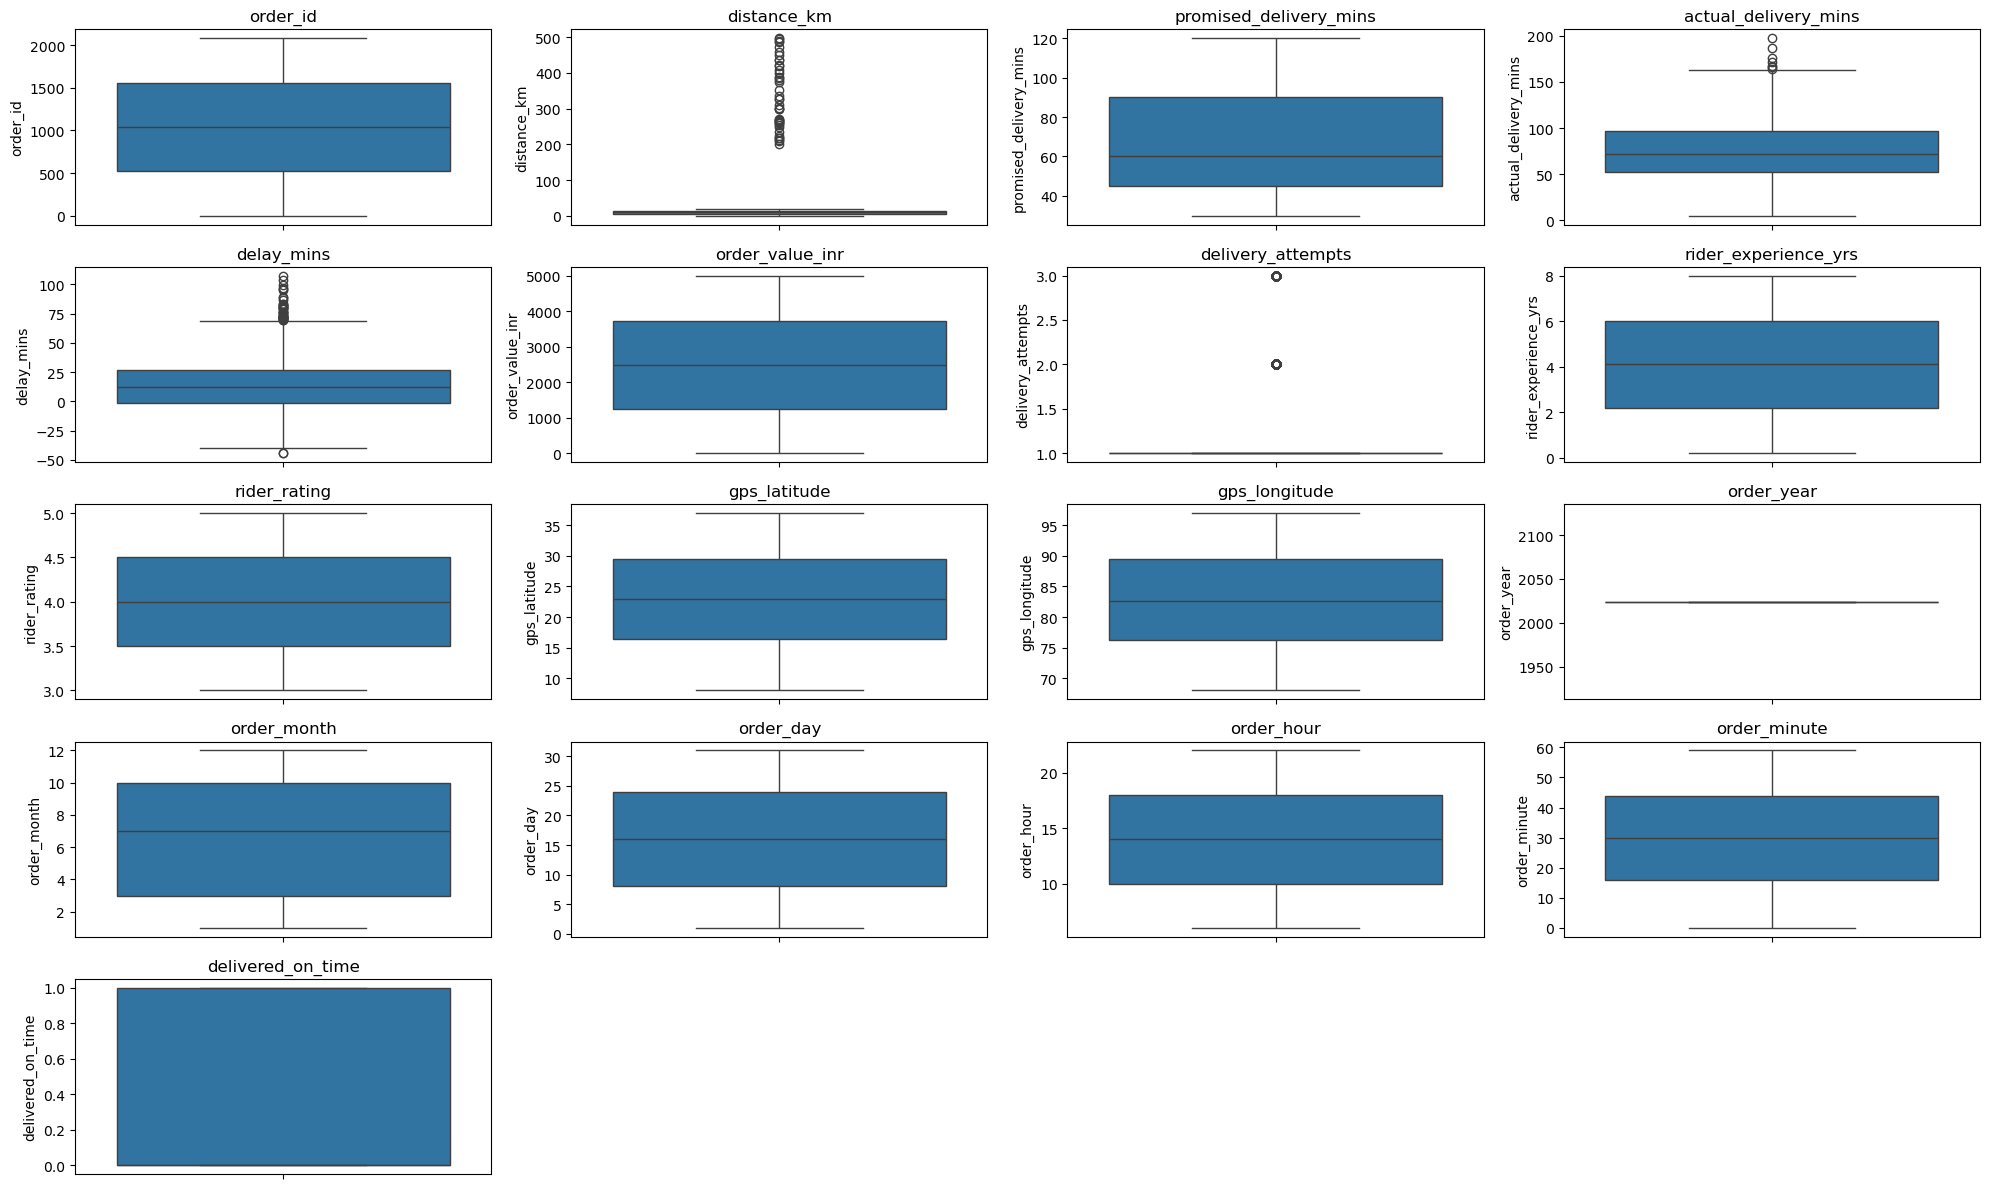

In [67]:
plt.figure(figsize=(20,12))

for i,col in enumerate(num_cols,1):
    plt.subplot(5,4,i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

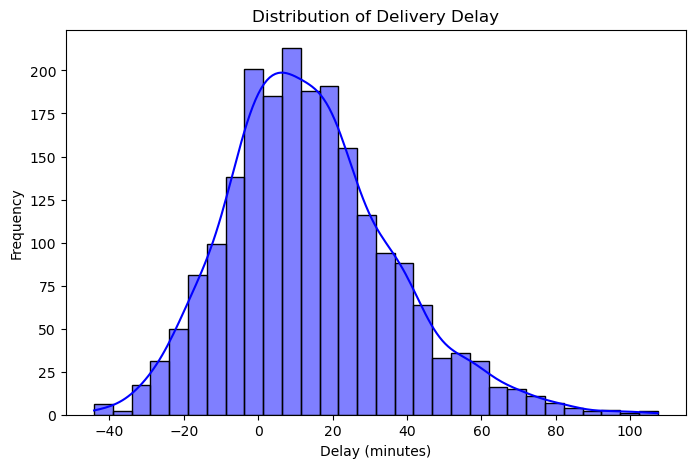

In [68]:
plt.figure(figsize=(8,5))
sns.histplot(df['delay_mins'], bins=30, kde=True, color='b')

plt.title("Distribution of Delivery Delay")
plt.xlabel("Delay (minutes)")
plt.ylabel("Frequency")

plt.show()

In [69]:
df['peak_hour'] = np.where(
    ((df['order_hour'] >= 8) & (df['order_hour'] <= 10)) |
    ((df['order_hour'] >= 17) & (df['order_hour'] <= 20)),
    'Peak',
    'Off-Peak'
)

In [70]:
df.groupby('peak_hour')['delay_mins'].agg(['count', 'mean', 'median'])

,count,mean,median
peak_hour,,,
Off-Peak,1211,7.381585,5.5
Peak,869,23.245800,20.5


In [71]:
peak_mean=df[df['peak_hour']=='Peak']['delay_mins'].mean()
offpeak_mean=df[df['peak_hour']!='Peak']['delay_mins'].mean()

In [72]:
difference = peak_mean - offpeak_mean

print(f"Peak Hour Mean Delay: {peak_mean:.2f} mins")
print(f"Off-Peak Mean Delay: {offpeak_mean:.2f} mins")
print(f"Difference: {difference:.2f} mins")

Peak Hour Mean Delay: 23.25 mins
Off-Peak Mean Delay: 7.38 mins
Difference: 15.86 mins


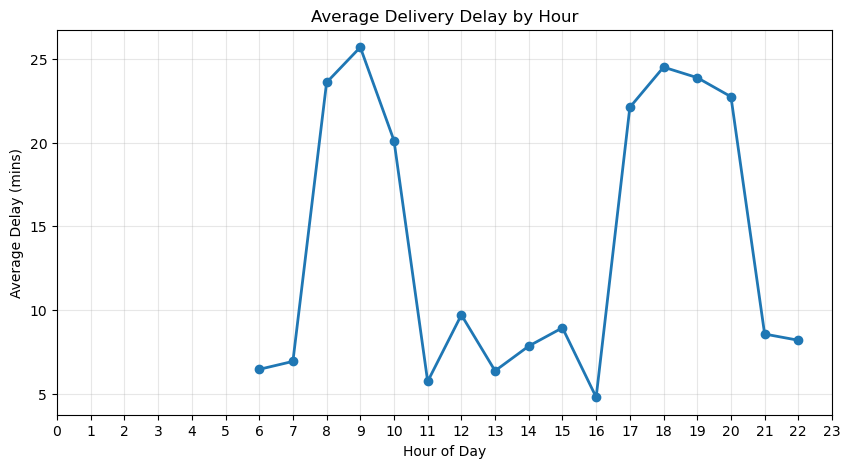

In [73]:
hourly_delay = df.groupby('order_hour')['delay_mins'].mean().reset_index()

plt.figure(figsize=(10,5))
plt.plot(hourly_delay['order_hour'],
         hourly_delay['delay_mins'],
         marker='o',
         linewidth=2)

plt.xticks(range(24))
plt.xlabel("Hour of Day")
plt.ylabel("Average Delay (mins)")
plt.title("Average Delivery Delay by Hour")
plt.grid(True, alpha=0.3)

plt.show()

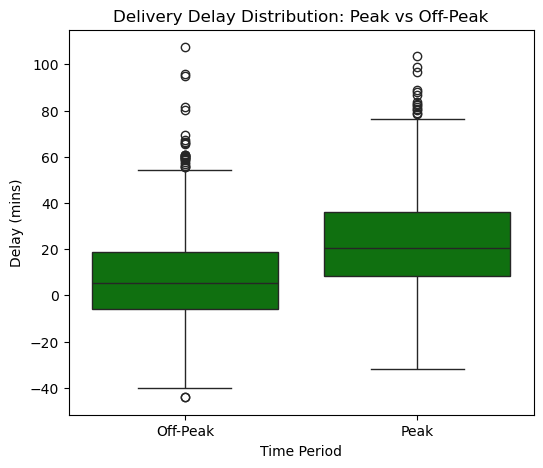

In [74]:
plt.figure(figsize=(6,5))
sns.boxplot(data=df, x='peak_hour', y='delay_mins',color='g')

plt.title('Delivery Delay Distribution: Peak vs Off-Peak')
plt.xlabel('Time Period')
plt.ylabel('Delay (mins)')

plt.show()

In [75]:
df.groupby('weather_condition')['delay_mins'].median().sort_values(ascending=False)

weather_condition
Fog              37.9
Rain             29.4
Clear             6.1
Partly Cloudy     5.5
Name: delay_mins, dtype: float64

In [76]:
rain = df[df['weather_condition'] == 'Rain']

rain.groupby('order_type')['delay_mins'].median().sort_values(ascending=False)

order_type
Medicine       34.65
Documents      29.80
Food           29.20
Grocery        29.05
Electronics    28.80
Apparel        27.10
Name: delay_mins, dtype: float64

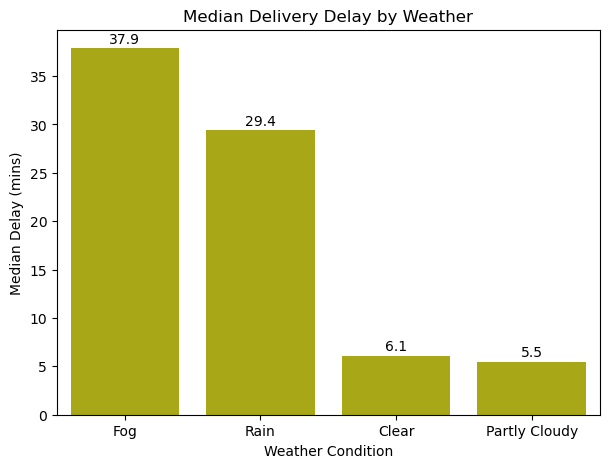

In [77]:
weather_delay = (
    df.groupby('weather_condition')['delay_mins']
      .median()
      .sort_values(ascending=False)
      .reset_index()
)

plt.figure(figsize=(7,5))
sns.barplot(data=weather_delay,
            x='weather_condition',
            y='delay_mins',color='y')

plt.title("Median Delivery Delay by Weather")
plt.xlabel("Weather Condition")
plt.ylabel("Median Delay (mins)")

for i, v in enumerate(weather_delay['delay_mins']):
    plt.text(i, v+0.5, f"{v:.1f}", ha='center')

plt.show()

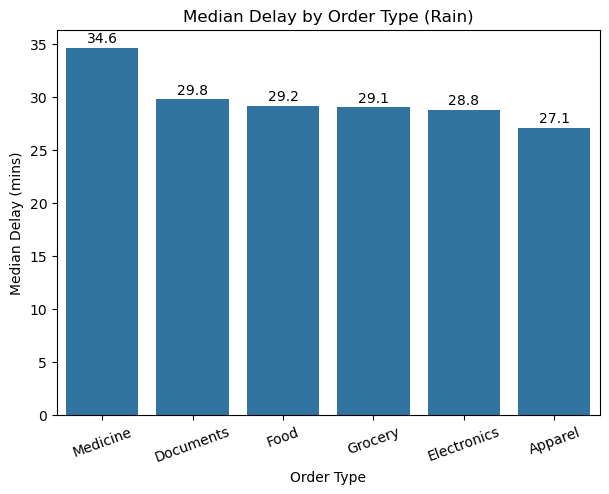

In [78]:
rain_delay = (
    df[df['weather_condition'] == 'Rain']
      .groupby('order_type')['delay_mins']
      .median()
      .sort_values(ascending=False)
      .reset_index()
)

plt.figure(figsize=(7,5))
sns.barplot(data=rain_delay,
            x='order_type',
            y='delay_mins')

plt.title("Median Delay by Order Type (Rain)")
plt.xlabel("Order Type")
plt.ylabel("Median Delay (mins)")

for i, v in enumerate(rain_delay['delay_mins']):
    plt.text(i, v+0.5, f"{v:.1f}", ha='center')

plt.xticks(rotation=20)
plt.show()

In [79]:
low_exp = df[df['rider_experience_yrs'] < 2]['delay_mins']
high_exp = df[df['rider_experience_yrs'] > 4]['delay_mins']

In [80]:
from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(low_exp, high_exp)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: -0.48059937602548974
P-value: 0.6308707413520651


In [81]:
print("Under 2 years Mean Delay:", low_exp.mean())
print("Over 4 years Mean Delay:", high_exp.mean())

Under 2 years Mean Delay: 13.746000000000002
Over 4 years Mean Delay: 14.348169014084508


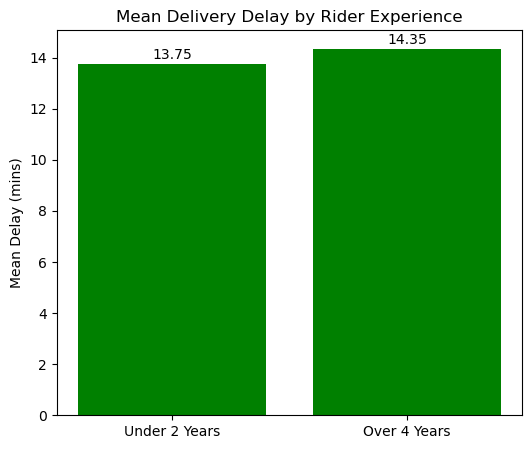

In [82]:
under2 = df[df['rider_experience_yrs'] < 2]['delay_mins'].mean()
over4 = df[df['rider_experience_yrs'] > 4]['delay_mins'].mean()

plt.figure(figsize=(6,5))

plt.bar(
    ['Under 2 Years', 'Over 4 Years'],
    [under2, over4],color='g'
)

plt.title('Mean Delivery Delay by Rider Experience')
plt.ylabel('Mean Delay (mins)')

for i, v in enumerate([under2, over4]):
    plt.text(i, v + 0.2, f'{v:.2f}', ha='center')

plt.show()

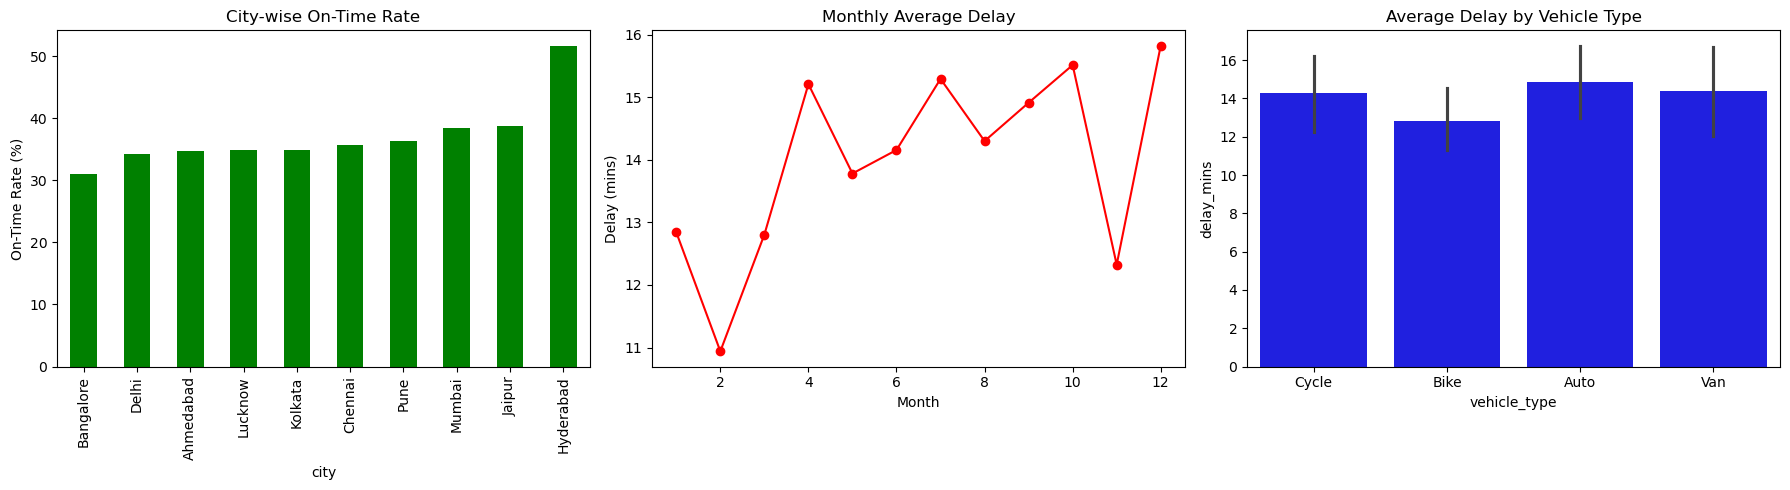

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(18,5))

city_rate = df.groupby('city')['delivered_on_time'].mean()*100
city_rate.sort_values().plot(kind='bar', ax=ax[0], color='green')
ax[0].set_title('City-wise On-Time Rate')
ax[0].set_ylabel('On-Time Rate (%)')

monthly_delay = df.groupby('order_month')['delay_mins'].mean()
monthly_delay.plot(marker='o', ax=ax[1], color='red')
ax[1].set_title('Monthly Average Delay')
ax[1].set_xlabel('Month')
ax[1].set_ylabel('Delay (mins)')

sns.barplot(data=df,
            x='vehicle_type',
            y='delay_mins',
            estimator='mean',
            ax=ax[2],
            color='b')
ax[2].set_title('Average Delay by Vehicle Type')

plt.tight_layout()
plt.show()